In [41]:
import zipfile
import os
import glob
import numpy as np
from tensorflow.keras.preprocessing import image

# step 1:- the uploaded file
train_path = "/kaggle/input/datasets/kritikseth/fruit-and-vegetable-image-recognition/train"

# step 2:- Check folder structure
print("Folders inside train folder:", os.listdir(train_path));

Folders inside train folder: ['capsicum', 'sweetcorn', 'orange', 'tomato', 'turnip', 'ginger', 'raddish', 'pomegranate', 'pineapple', 'jalepeno', 'apple', 'carrot', 'lettuce', 'bell pepper', 'eggplant', 'beetroot', 'kiwi', 'pear', 'cabbage', 'cauliflower', 'paprika', 'lemon', 'sweetpotato', 'grapes', 'cucumber', 'corn', 'banana', 'garlic', 'chilli pepper', 'watermelon', 'mango', 'peas', 'onion', 'potato', 'spinach', 'soy beans']


In [42]:
# Get Fruit and vegetables
fruit_classes = [
    'sweetcorn','orange','pomegranate','pineapple','apple','pear',
    'lemon','sweetpotato','grapes','cucumber','kiwi','corn',
    'banana','watermelon','mango'
]

fruit_paths = []
for cls in fruit_classes:
    fruit_paths += glob.glob(os.path.join(train_path, cls, '*'))


In [43]:
vegetable_classes = [
    'capsicum','tomato','turnip','ginger','raddish','jalepeno',
    'carrot','lettuce','bell pepper','eggplant','beetroot',
    'cabbage','cauliflower','paprika','garlic','chilli pepper',
    'peas','onion','potato','spinach','soy beans'
]

vegetable_paths = []
for cls in vegetable_classes:
    vegetable_paths += glob.glob(os.path.join(train_path, cls, '*'))

In [44]:
print('Found', len(fruit_paths), 'fruit images')
print('Found', len(vegetable_paths), 'vegetable images')

Found 1260 fruit images
Found 1855 vegetable images


In [45]:
#step 4:- Create empty lists

data = [] #X images
labels = [] #y name

In [46]:
# Step 5:- Load and preprocess Fruit images


for path in fruit_paths:

    # Load image and resize to 150x150
    img = image.load_img(path, target_size=(150, 150))

    # Convert image to numpy array
    img_array = image.img_to_array(img)

    # Normalize pixel values from [0,255] → [0,1]
    img_array = img_array / 255.0

    # Store processed image
    data.append(img_array)

    # Assign label 0 for Fruit (target)
    labels.append(0)


In [47]:
# step 6:- Load and preprocess Vegetable images


for path in vegetable_paths:

    # Load image and resize to 150x150
    img = image.load_img(path, target_size=(150, 150))

    # Convert image to numpy array
    img_array = image.img_to_array(img)

    # Normalize pixel values
    img_array = img_array / 255.0

    # Store processed image
    data.append(img_array)

    # Assign label 1 for vegetable
    labels.append(1)

In [48]:
# step 7:-  CNN models require numpy arrays
x = np.array(data)      # Image data
y = np.array(labels)

In [49]:
# Step 8:- Check dataset structure
print("Data shape:", x.shape)   # (num_images, 150, 150, 3)
print(" Labels:", y)

Data shape: (3115, 150, 150, 3)
 Labels: [0 0 0 ... 1 1 1]


In [50]:
#step 9:- Create an empty list to store labels
labels = []

# Loop through all fruit image paths
for path in fruit_paths:
    # Add label 'fruit' for each fruit image
    labels.append('fruit')

# Loop through all vegetable image paths
for path in vegetable_paths:
    # Add label 'vegetable' for each vegetable image
    labels.append('vegetable')

# Example output
# This will print labels corresponding to the images
print(labels) 

['fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 'fruit', 

In [51]:
# step 10:-  Convert labels to one-hot
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical

y_data = to_categorical(y)
y_data

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [52]:
# step 11:- Build CNN
model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(150, 150, 3)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax')
])

# step 12:- Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# step 13:- Train
model.fit(x, y_data, epochs=10, batch_size=32)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.6033 - loss: 0.6910
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.6684 - loss: 0.6010
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.7313 - loss: 0.5618
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.7419 - loss: 0.5159
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.7443 - loss: 0.5209
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.7570 - loss: 0.4922
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.8126 - loss: 0.4119
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.8232 - loss: 0.3723
Epoch 9/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.8842 - loss: 0.2688
Epoch 10/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.9103 - loss: 0.2210


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted label for /kaggle/input/datasets/kritikseth/fruit-and-vegetable-image-recognition/test/banana/Image_5.jpg: fruit


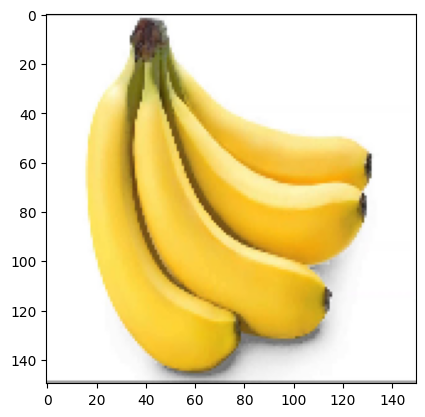

In [55]:
from tensorflow.keras.preprocessing import image
import numpy as np

# upload a new image
import matplotlib.pyplot as plt
from google.colab import files

# Upload a image from test folder (A fruit)
Test_path = "/kaggle/input/datasets/kritikseth/fruit-and-vegetable-image-recognition/test/banana"

apple_images = glob.glob(os.path.join(Test_path, '*'))

apple = apple_images[2]

img = image.load_img(apple, target_size=(150, 150))
plt.imshow(img)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

pred = model.predict(img_array)
class_idx = np.argmax(pred)
label = "fruit" if class_idx == 0 else "vegetable"
print(f"Predicted label for {apple}: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted label for /kaggle/input/datasets/kritikseth/fruit-and-vegetable-image-recognition/test/chilli pepper/Image_6.jpeg: vegetable


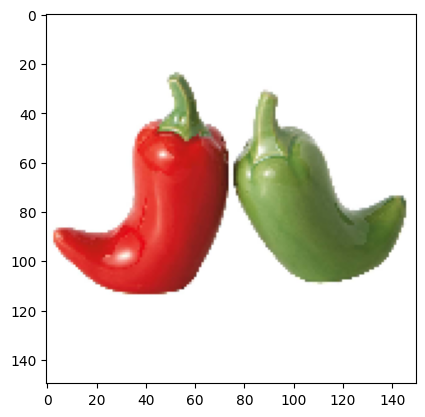

In [57]:

# Upload a image from test folder (A vegetable)
Test_path = "/kaggle/input/datasets/kritikseth/fruit-and-vegetable-image-recognition/test/chilli pepper"

pepper_images = glob.glob(os.path.join(Test_path, '*'))

pepper = pepper_images[2]

img = image.load_img(pepper, target_size=(150, 150))
plt.imshow(img)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

pred = model.predict(img_array)
class_idx = np.argmax(pred)
label = "fruit" if class_idx == 0 else "vegetable"
print(f"Predicted label for {pepper}: {label}")